In [ ]:
!pip install ucimlrepo -q
!pip install imbalanced-learn -q
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

In [ ]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [ ]:
from ucimlrepo import fetch_ucirepo

steel_plates = fetch_ucirepo(id=198)

In [ ]:
# Features (27 predictors = reasons causing defects)
X = steel_plates.data.features

# 7 binary target columns
y_multi = steel_plates.data.targets

print("Dataset loaded!")
print("Shape of features:", X.shape)
print("7 binary target columns:", y_multi.columns.tolist())

Dataset loaded!
Shape of features: (1941, 27)
7 binary target columns: ['Pastry', 'Z_Scratch', 'K_Scratch', 'Stains', 'Dirtiness', 'Bumps', 'Other_Faults']


In [ ]:
# Step 3: Create single target column "Fault_Type"
fault_columns = ['Pastry', 'Z_Scratch', 'K_Scatch', 'Stains', 'Dirtiness', 'Bumps', 'Other_Faults']

In [ ]:
y = y_multi.idxmax(axis=1)

print("Target created successfully!")
print("Unique defect types (7 classes):")
print(y.value_counts().sort_index())

Target created successfully!
Unique defect types (7 classes):
Bumps           402
Dirtiness        55
K_Scratch       391
Other_Faults    673
Pastry          158
Stains           72
Z_Scratch       190
Name: count, dtype: int64


In [ ]:
# Step 4: Drop the 7 binary columns (we don't need them anymore)
X = X.copy()  # safety copy
print("Final shape → Features:", X.shape, "| Target:", y.shape)

Final shape → Features: (1941, 27) | Target: (1941,)


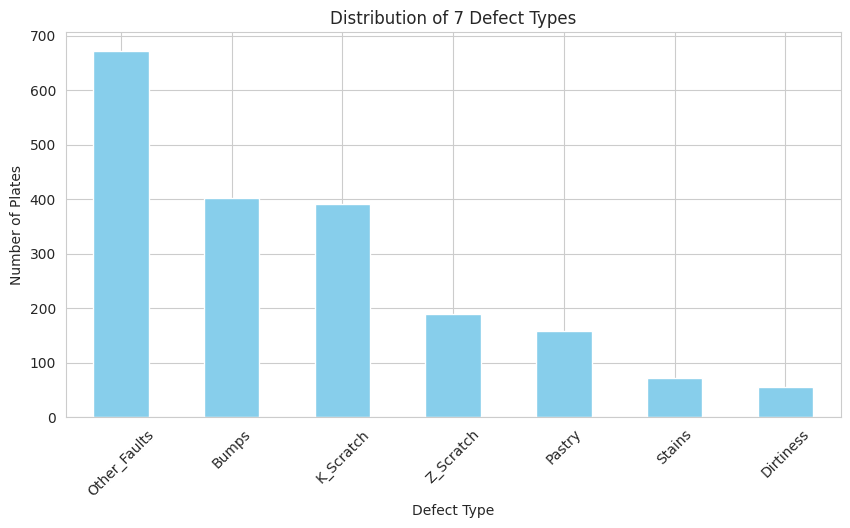


Class distribution:
 Other_Faults    0.347
Bumps           0.207
K_Scratch       0.201
Z_Scratch       0.098
Pastry          0.081
Stains          0.037
Dirtiness       0.028
Name: proportion, dtype: float64


In [ ]:
plt.figure(figsize=(10,5))
y.value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribution of 7 Defect Types')
plt.xlabel('Defect Type')
plt.ylabel('Number of Plates')
plt.xticks(rotation=45)
plt.show()

print("\nClass distribution:\n", y.value_counts(normalize=True).round(3))

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Create encoder and transform
le = LabelEncoder()
y_numeric = le.fit_transform(y)          # y is the current pandas Series with strings

# Show mapping so you know which number = which defect
mapping = dict(zip(le.classes_, range(len(le.classes_))))
print("Label mapping:")
for defect, num in sorted(mapping.items()):
    print(f"{num:2d} ← {defect}")

# Overwrite y with numeric version
y = y_numeric

print("\nTarget is now numeric. Sample values:", y[:8])
print("Unique values:", np.unique(y))

Label mapping:
 0 ← Bumps
 1 ← Dirtiness
 2 ← K_Scratch
 3 ← Other_Faults
 4 ← Pastry
 5 ← Stains
 6 ← Z_Scratch

Target is now numeric. Sample values: [4 4 4 4 4 4 4 4]
Unique values: [0 1 2 3 4 5 6]


=== Class Distribution ===
0    402
1     55
2    391
3    673
4    158
5     72
6    190
Name: count, dtype: int64

=== Percentage Distribution ===
0    20.71
1     2.83
2    20.14
3    34.67
4     8.14
5     3.71
6     9.79
Name: proportion, dtype: float64


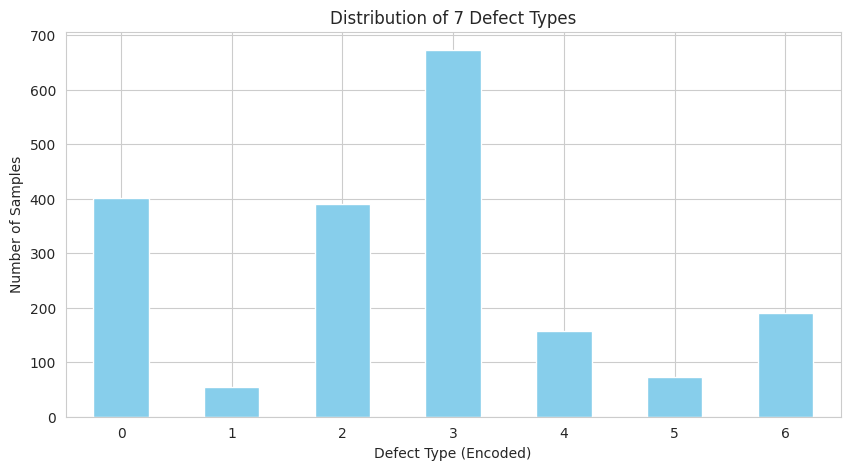


Class Mapping:
0 → Bumps
1 → Dirtiness
2 → K_Scratch
3 → Other_Faults
4 → Pastry
5 → Stains
6 → Z_Scratch


In [ ]:
# === Check Class Balance ===

# Convert to pandas Series so we can use value_counts()
y_series = pd.Series(y)

print("=== Class Distribution ===")
print(y_series.value_counts().sort_index())

print("\n=== Percentage Distribution ===")
print((y_series.value_counts(normalize=True).round(4) * 100).sort_index())

# Visual check
plt.figure(figsize=(10, 5))
y_series.value_counts().sort_index().plot(kind='bar', color='skyblue')
plt.title('Distribution of 7 Defect Types')
plt.xlabel('Defect Type (Encoded)')
plt.ylabel('Number of Samples')
plt.xticks(rotation=0)
plt.show()

# Show mapping
print("\nClass Mapping:")
for i, name in enumerate(['Bumps', 'Dirtiness', 'K_Scratch', 'Other_Faults',
                          'Pastry', 'Stains', 'Z_Scratch']):
    print(f"{i} → {name}")

In [ ]:
from imblearn.over_sampling import SMOTE
import pandas as pd

print("Original training set class distribution:")
print(pd.Series(y_train).value_counts().sort_index())

# Apply SMOTE
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE - New training set class distribution:")
print(pd.Series(y_train_smote).value_counts().sort_index())
print(f"\nTraining samples increased from {len(X_train)} to {len(X_train_smote)}")

Original training set class distribution:
0    301
1     41
2    293
3    505
4    119
5     54
6    142
Name: count, dtype: int64

After SMOTE - New training set class distribution:
0    505
1    505
2    505
3    505
4    505
5    505
6    505
Name: count, dtype: int64

Training samples increased from 1455 to 3535


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Train size: {X_train_smote.shape[0]} rows")
print(f"Test size:  {X_test.shape[0]} rows")

Train size: 3535 rows
Test size:  486 rows


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), X.columns.tolist())
    ])

In [ ]:
# Logistic Regression
lr_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(multi_class='multinomial',
        solver='lbfgs', max_iter=3000, random_state=42))
])

# Random Forest
rf_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=400, max_depth=15, random_state=42, n_jobs=-1))
])

# XGBoost
xgb_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        objective='multi:softprob',
        num_class=7,
        max_depth=8,
        learning_rate=0.08,
        n_estimators=400,
        subsample=0.85,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        eval_metric='mlogloss'))
])

print("✅ 3 models ready!")

✅ 3 models ready!


In [ ]:
print("Training models...\n")

lr_pipe.fit(X_train, y_train)
print("Logistic Regression → Done")

rf_pipe.fit(X_train, y_train)
print("Random Forest → Done")

xgb_pipe.fit(X_train, y_train)
print("XGBoost → Done")

Training models...

Logistic Regression → Done


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Random Forest → Done
XGBoost → Done


In [ ]:
# Step 10: Evaluation
def evaluate_model_full(pipe, name, X_test=X_test, y_test=y_test, target_names=None):
    """
    Comprehensive evaluation:
    - Accuracy
    - Precision / Recall / F1 per class + macro average
    - Confusion matrix heatmap
    """
    y_pred = pipe.predict(X_test)

    # 1. Accuracy
    acc = accuracy_score(y_test, y_pred)

    # 2. Precision, Recall, F1 per class + macro
    precision, recall, f1, support = precision_recall_fscore_support(
        y_test, y_pred,
        labels=range(len(target_names)) if target_names else None,
        zero_division=0
    )

    macro_precision = precision.mean()
    macro_recall    = recall.mean()
    macro_f1        = f1.mean()

    # Print header
    print(f"\n{'='*70}")
    print(f"Evaluation: {name}")
    print(f"{'='*70}")

    # Accuracy
    print(f"Accuracy:          {acc:.4f}")

    # Macro averages
    print(f"Macro Precision:   {macro_precision:.4f}")
    print(f"Macro Recall:      {macro_recall:.4f}")
    print(f"Macro F1-score:    {macro_f1:.4f}\n")

    # Detailed per-class report
    if target_names:
        print("Per-class metrics:")
        print("Class".ljust(18) + "Precision".rjust(12) + "Recall".rjust(10) + "F1".rjust(10) + "Support".rjust(10))
        print("-" * 60)
        for i, cls in enumerate(target_names):
            print(f"{cls:<18} {precision[i]:>12.4f} {recall[i]:>10.4f} {f1[i]:>10.4f} {support[i]:>10}")
    else:
        print(classification_report(y_test, y_pred, digits=4))

    # 3. Confusion Matrix - Heatmap
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=target_names,
        yticklabels=target_names,
        cbar=False
    )
    plt.title(f'Confusion Matrix – {name}\nAccuracy: {acc:.4f}', fontsize=14, pad=20)
    plt.ylabel('Actual label', fontsize=12)
    plt.xlabel('Predicted label', fontsize=12)
    plt.tight_layout()
    plt.show()

    print("\n")

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)


Evaluation: Logistic Regression
Accuracy:          0.7222
Macro Precision:   0.7632
Macro Recall:      0.7113
Macro F1-score:    0.7316

Per-class metrics:
Class                Precision    Recall        F1   Support
------------------------------------------------------------
Bumps                    0.6750     0.5347     0.5967        101
Dirtiness                0.9000     0.6429     0.7500         14
K_Scratch                0.9468     0.9082     0.9271         98
Other_Faults             0.6219     0.7440     0.6775        168
Pastry                   0.5455     0.4615     0.5000         39
Stains                   0.8333     0.8333     0.8333         18
Z_Scratch                0.8200     0.8542     0.8367         48


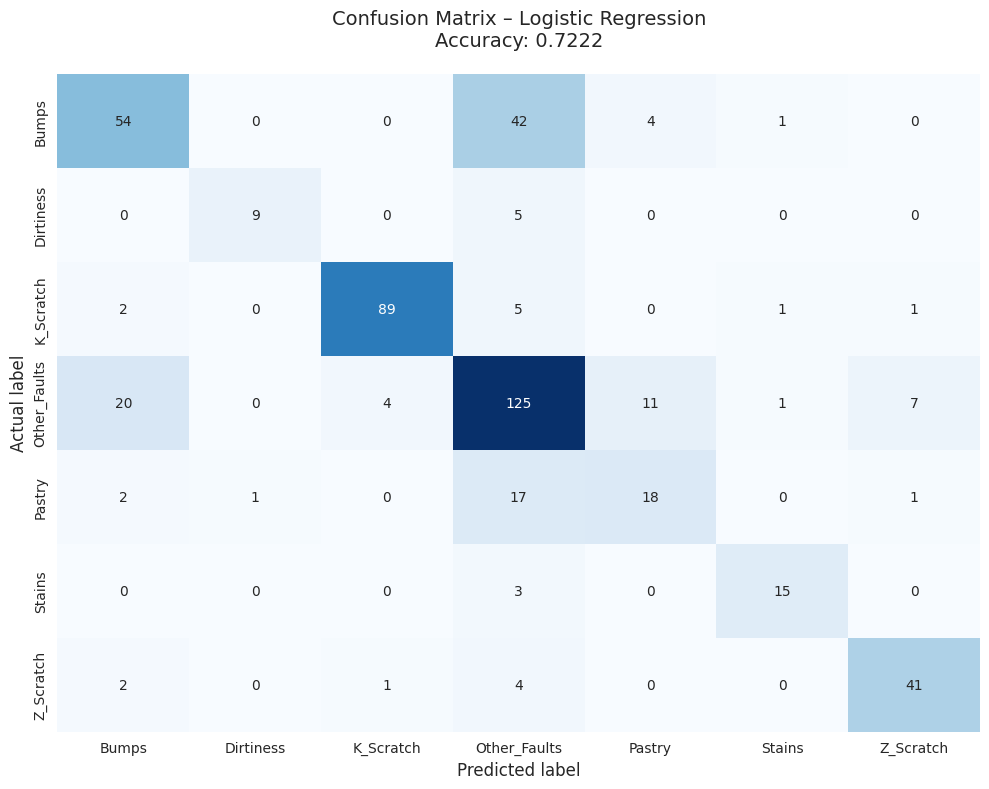




Evaluation: Random Forest
Accuracy:          0.7922
Macro Precision:   0.8439
Macro Recall:      0.7705
Macro F1-score:    0.8018

Per-class metrics:
Class                Precision    Recall        F1   Support
------------------------------------------------------------
Bumps                    0.7273     0.7129     0.7200        101
Dirtiness                0.9231     0.8571     0.8889         14
K_Scratch                0.9677     0.9184     0.9424         98
Other_Faults             0.7020     0.8274     0.7596        168
Pastry                   0.6786     0.4872     0.5672         39
Stains                   0.9333     0.7778     0.8485         18
Z_Scratch                0.9750     0.8125     0.8864         48


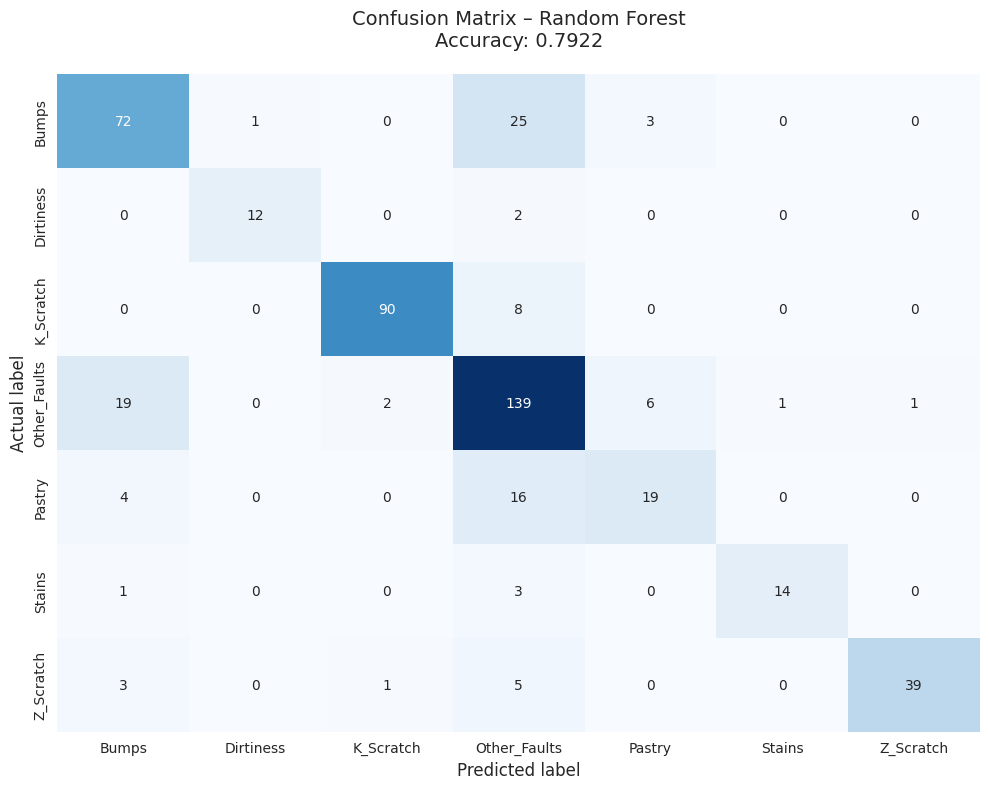




Evaluation: XGBoost
Accuracy:          0.8066
Macro Precision:   0.8408
Macro Recall:      0.7992
Macro F1-score:    0.8175

Per-class metrics:
Class                Precision    Recall        F1   Support
------------------------------------------------------------
Bumps                    0.7447     0.6931     0.7179        101
Dirtiness                0.8571     0.8571     0.8571         14
K_Scratch                0.9681     0.9286     0.9479         98
Other_Faults             0.7366     0.8155     0.7740        168
Pastry                   0.5789     0.5641     0.5714         39
Stains                   1.0000     0.7778     0.8750         18
Z_Scratch                1.0000     0.9583     0.9787         48


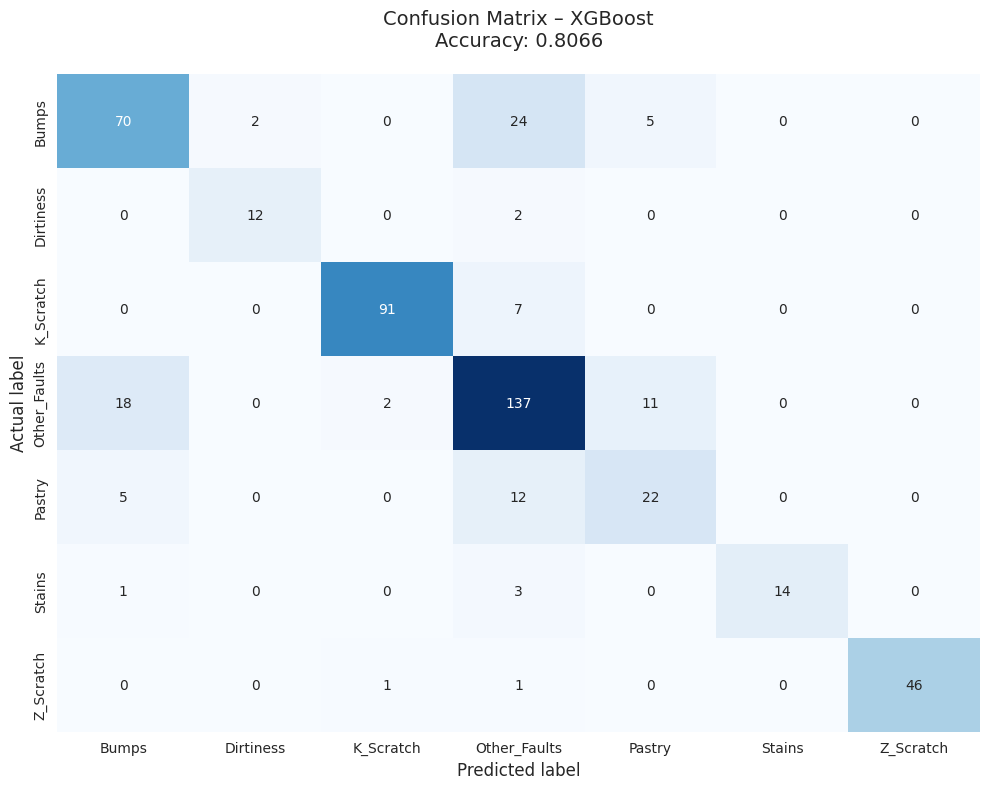

In [ ]:
class_names = le.classes_.tolist()

# Evaluate the three models
evaluate_model_full(lr_pipe,     "Logistic Regression",     X_test=X_test, y_test=y_test, target_names=class_names)
evaluate_model_full(rf_pipe,     "Random Forest",           X_test=X_test, y_test=y_test, target_names=class_names)
evaluate_model_full(xgb_pipe,    "XGBoost",                 X_test=X_test, y_test=y_test, target_names=class_names)

In [ ]:
## With SMOTE
# Logistic Regression
lr_smote = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(multi_class='multinomial',
        solver='lbfgs', max_iter=3000, random_state=42))
])

# Random Forest
rf_smote = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=400, max_depth=15, random_state=42, n_jobs=-1))
])

# XGBoost
xgb_smote = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        objective='multi:softprob',
        num_class=7,
        max_depth=8,
        learning_rate=0.08,
        n_estimators=400,
        subsample=0.85,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        eval_metric='mlogloss'))
])

print("✅ 3 models ready!")

✅ 3 models ready!


In [ ]:
print("Training models with SMOTE data...\n")

lr_smote.fit(X_train_smote, y_train_smote)
print("Logistic Regression (SMOTE) → Done")

rf_smote.fit(X_train_smote, y_train_smote)
print("Random Forest (SMOTE) → Done")

xgb_smote.fit(X_train_smote, y_train_smote)
print("XGBoost (SMOTE) → Done")

Training models with SMOTE data...



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression (SMOTE) → Done
Random Forest (SMOTE) → Done
XGBoost (SMOTE) → Done


=== Results After Applying SMOTE ===


Evaluation: Logistic Regression + SMOTE
Accuracy:          0.6852
Macro Precision:   0.6462
Macro Recall:      0.7499
Macro F1-score:    0.6729

Per-class metrics:
Class                Precision    Recall        F1   Support
------------------------------------------------------------
Bumps                    0.6531     0.6337     0.6432        101
Dirtiness                0.3077     0.8571     0.4528         14
K_Scratch                0.9286     0.9286     0.9286         98
Other_Faults             0.7265     0.5060     0.5965        168
Pastry                   0.4211     0.6154     0.5000         39
Stains                   0.7500     0.8333     0.7895         18
Z_Scratch                0.7368     0.8750     0.8000         48


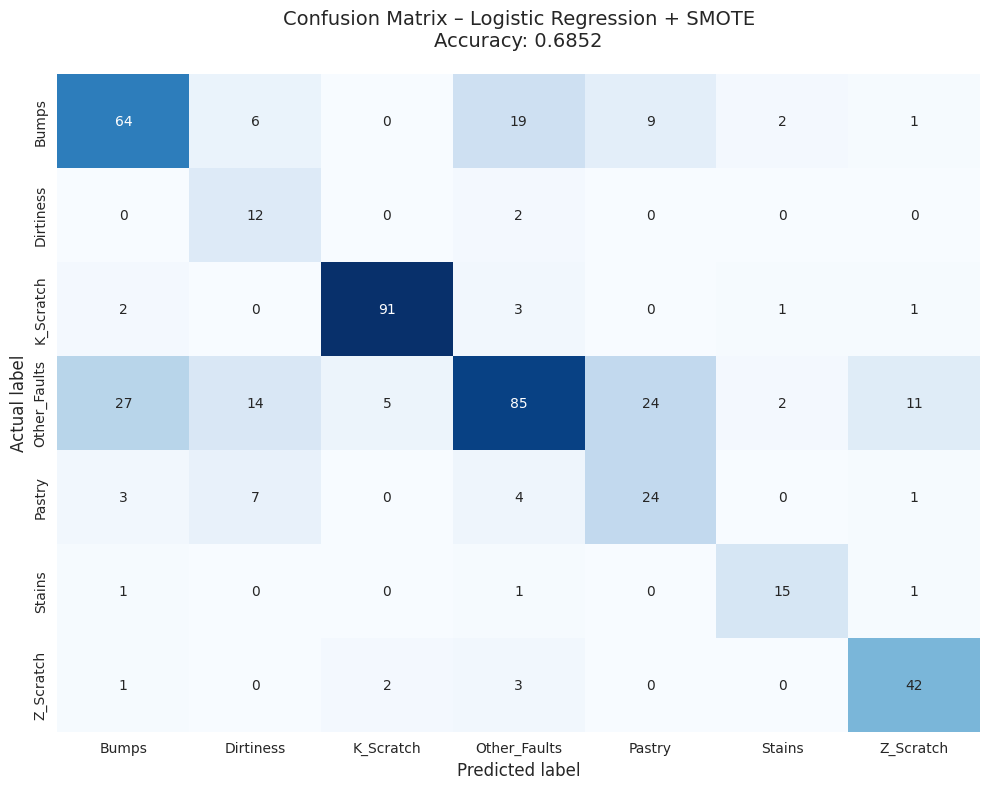




Evaluation: Random Forest + SMOTE
Accuracy:          0.7901
Macro Precision:   0.8339
Macro Recall:      0.8091
Macro F1-score:    0.8188

Per-class metrics:
Class                Precision    Recall        F1   Support
------------------------------------------------------------
Bumps                    0.7196     0.7624     0.7404        101
Dirtiness                1.0000     0.9286     0.9630         14
K_Scratch                0.9583     0.9388     0.9485         98
Other_Faults             0.7407     0.7143     0.7273        168
Pastry                   0.5306     0.6667     0.5909         39
Stains                   0.9333     0.7778     0.8485         18
Z_Scratch                0.9545     0.8750     0.9130         48


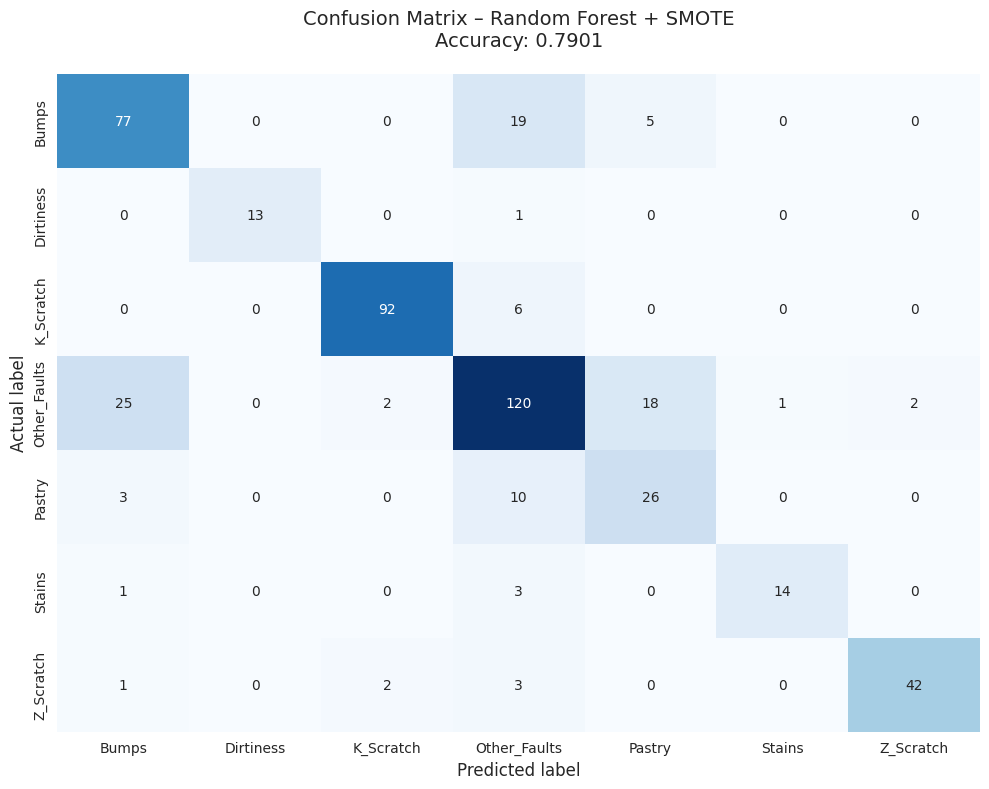




Evaluation: XGBoost + SMOTE
Accuracy:          0.8086
Macro Precision:   0.8288
Macro Recall:      0.8112
Macro F1-score:    0.8183

Per-class metrics:
Class                Precision    Recall        F1   Support
------------------------------------------------------------
Bumps                    0.7826     0.7129     0.7461        101
Dirtiness                0.8667     0.9286     0.8966         14
K_Scratch                0.9681     0.9286     0.9479         98
Other_Faults             0.7459     0.8036     0.7736        168
Pastry                   0.5476     0.5897     0.5679         39
Stains                   0.9333     0.7778     0.8485         18
Z_Scratch                0.9574     0.9375     0.9474         48


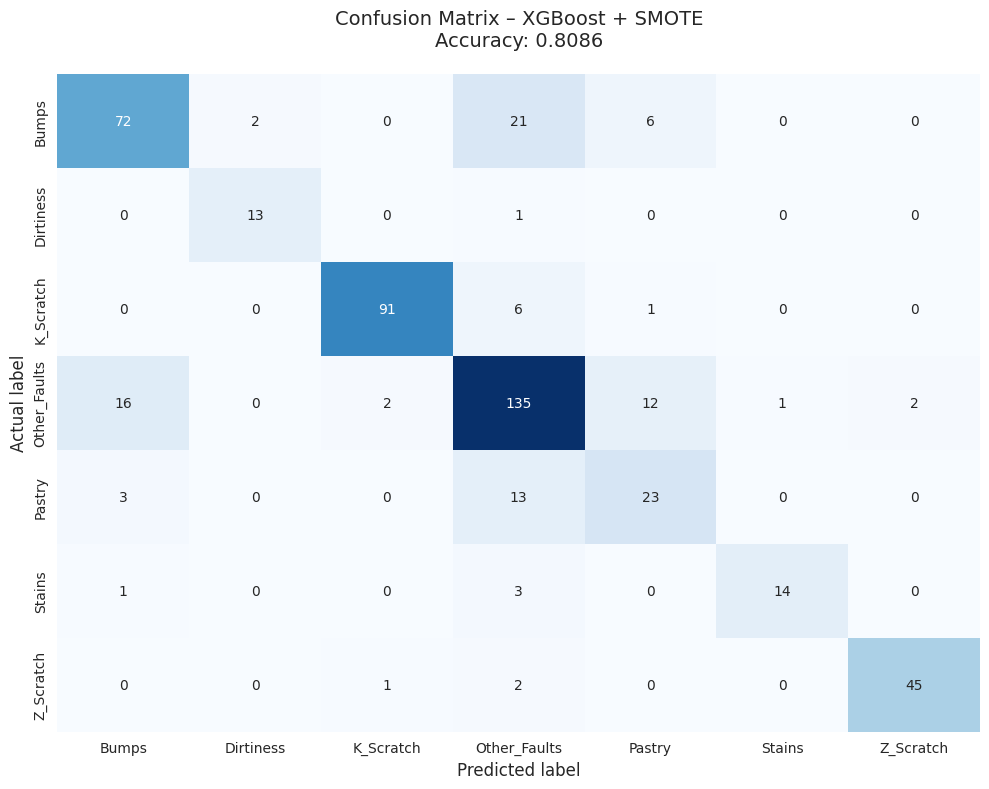

In [ ]:
class_names = ['Bumps', 'Dirtiness', 'K_Scratch', 'Other_Faults',
               'Pastry', 'Stains', 'Z_Scratch']

print("=== Results After Applying SMOTE ===\n")

evaluate_model_full(lr_smote,  "Logistic Regression + SMOTE",
                    X_test=X_test, y_test=y_test, target_names=class_names)

evaluate_model_full(rf_smote,  "Random Forest + SMOTE",
                    X_test=X_test, y_test=y_test, target_names=class_names)

evaluate_model_full(xgb_smote, "XGBoost + SMOTE",
                    X_test=X_test, y_test=y_test, target_names=class_names)

In [ ]:
print("\nFinal Comparison: Before vs After SMOTE")
print("-"*75)
print(f"{'Model':<30} {'Accuracy':>10} {'Macro F1':>12}")
print("-"*75)

# Old models (without SMOTE)
for name, pipe in [("Old Logistic", lr_pipe), ("Old RF", rf_pipe), ("Old XGBoost", xgb_pipe)]:
    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    print(f"{name:<30} {acc:>10.4f} {f1:>12.4f}")

# SMOTE models
print("-"*75)
for name, pipe in [("Logistic + SMOTE", lr_smote), ("RF + SMOTE", rf_smote), ("XGBoost + SMOTE", xgb_smote)]:
    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    print(f"{name:<30} {acc:>10.4f} {f1:>12.4f}")


Final Comparison: Before vs After SMOTE
---------------------------------------------------------------------------
Model                            Accuracy     Macro F1
---------------------------------------------------------------------------
Old Logistic                       0.7140       0.6706
Old RF                             0.6337       0.4739
Old XGBoost                        0.6646       0.4973
---------------------------------------------------------------------------
Logistic + SMOTE                   0.6852       0.6729
RF + SMOTE                         0.7901       0.8188
XGBoost + SMOTE                    0.8086       0.8183


In [ ]:
y_pred_lr  = lr_smote.predict(X_test)
y_pred_rf  = rf_smote.predict(X_test)
y_pred_xgb = xgb_smote.predict(X_test)

print("Predictions generated for all 3 models.")

Predictions generated for all 3 models.


In [ ]:
model_name = "XGBoost"          # Change to "Logistic Regression" or "Random Forest" if you want
y_pred = y_pred_xgb             # Change to y_pred_lr or y_pred_rf accordingly

comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

# Add class names for better readability
class_names = ['Bumps', 'Dirtiness', 'K_Scratch', 'Other_Faults',
               'Pastry', 'Stains', 'Z_Scratch']

comparison['Actual_Name']    = comparison['Actual'].map(lambda x: class_names[x])
comparison['Predicted_Name'] = comparison['Predicted'].map(lambda x: class_names[x])

print(f"First 10 Actual vs Predicted ({model_name}):")
print(comparison.head(10))

First 10 Actual vs Predicted (XGBoost):
   Actual  Predicted   Actual_Name Predicted_Name
0       0          3         Bumps   Other_Faults
1       3          3  Other_Faults   Other_Faults
2       2          2     K_Scratch      K_Scratch
3       3          3  Other_Faults   Other_Faults
4       6          6     Z_Scratch      Z_Scratch
5       5          5        Stains         Stains
6       0          1         Bumps      Dirtiness
7       0          0         Bumps          Bumps
8       3          3  Other_Faults   Other_Faults
9       4          3        Pastry   Other_Faults


/tmp/ipykernel_4710/2210633195.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=comparison, x='Actual_Name', order=class_names, palette='Blues')
/tmp/ipykernel_4710/2210633195.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=comparison, x='Predicted_Name', order=class_names, palette='Oranges')


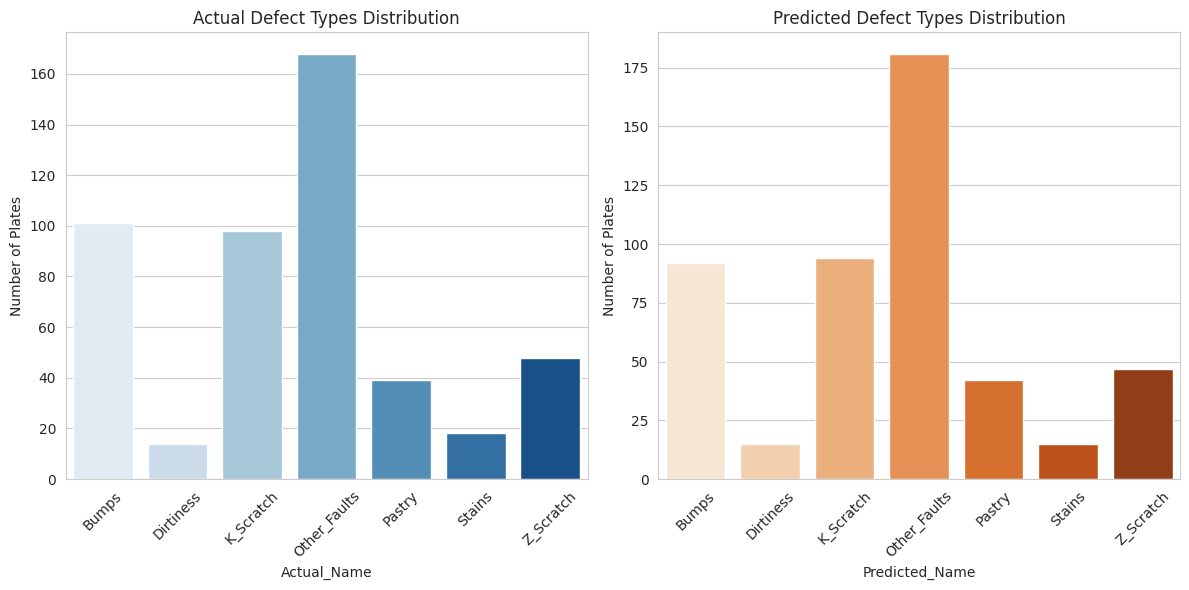

In [ ]:
plt.figure(figsize=(12, 6))

# Actual distribution
plt.subplot(1, 2, 1)
sns.countplot(data=comparison, x='Actual_Name', order=class_names, palette='Blues')
plt.title('Actual Defect Types Distribution')
plt.xticks(rotation=45)
plt.ylabel('Number of Plates')

# Predicted distribution
plt.subplot(1, 2, 2)
sns.countplot(data=comparison, x='Predicted_Name', order=class_names, palette='Oranges')
plt.title('Predicted Defect Types Distribution')
plt.xticks(rotation=45)
plt.ylabel('Number of Plates')

plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

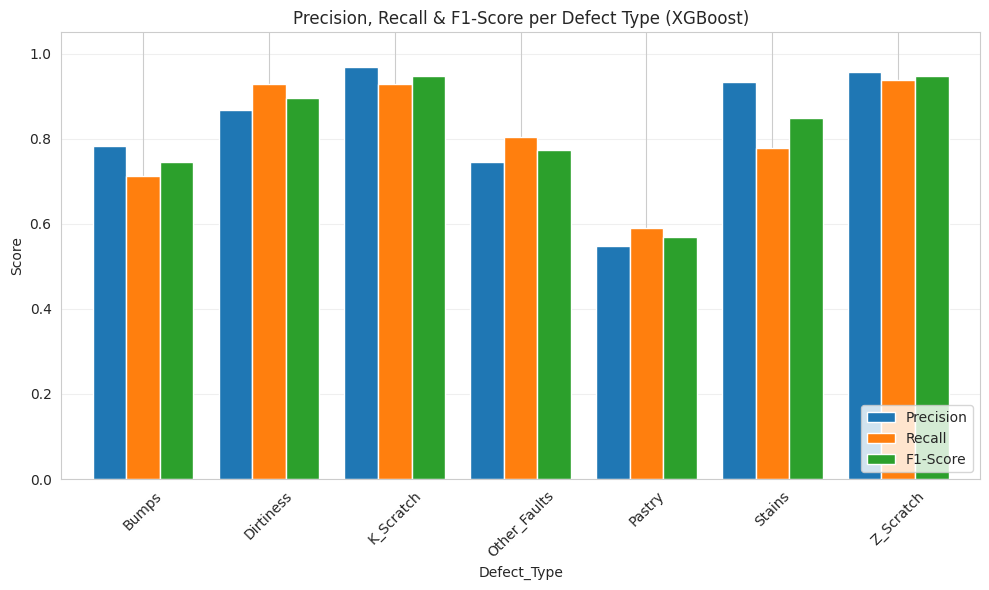

In [ ]:
from sklearn.metrics import precision_recall_fscore_support

# Choose the model you want to visualize (change here)
chosen_pred = y_pred_xgb          # Change to y_pred_lr or y_pred_rf if needed
chosen_name = "XGBoost"

precision, recall, f1, support = precision_recall_fscore_support(
    y_test, chosen_pred, average=None, zero_division=0
)

class_acc = pd.DataFrame({
    'Defect_Type': class_names,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1
})

# Plot
plt.figure(figsize=(10, 6))
class_acc.set_index('Defect_Type')[['Precision', 'Recall', 'F1-Score']].plot(kind='bar', width=0.8)
plt.title(f'Precision, Recall & F1-Score per Defect Type ({chosen_name})')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

The 'Precision, Recall & F1-Score per Defect Type (XGBoost)' graph provides a detailed view of the XGBoost model's performance for each specific defect type.


**Excellent Performance:** The model shows outstanding performance for 'K_Scratch' (F1: 0.94), 'Z_Scratch' (F1: 0.97), and 'Stains' (F1: 0.88), with 'Stains' and 'Z_Scratch' achieving perfect precision.

**Strong Performance:** 'Dirtiness' (F1: 0.86) also exhibits strong and balanced precision and recall. 'Other_Faults' (F1: 0.78) and 'Bumps' (F1: 0.74) demonstrate good overall performance, though 'Other_Faults' has slightly higher recall than precision, and 'Bumps' is more balanced.

**Moderate Performance:** 'Pastry' (F1: 0.55) is the most challenging defect type for the model, showing the lowest precision, recall, and F1-score among all classes. This indicates that the model struggles most with correctly identifying 'Pastry' defects without significant errors or omissions.

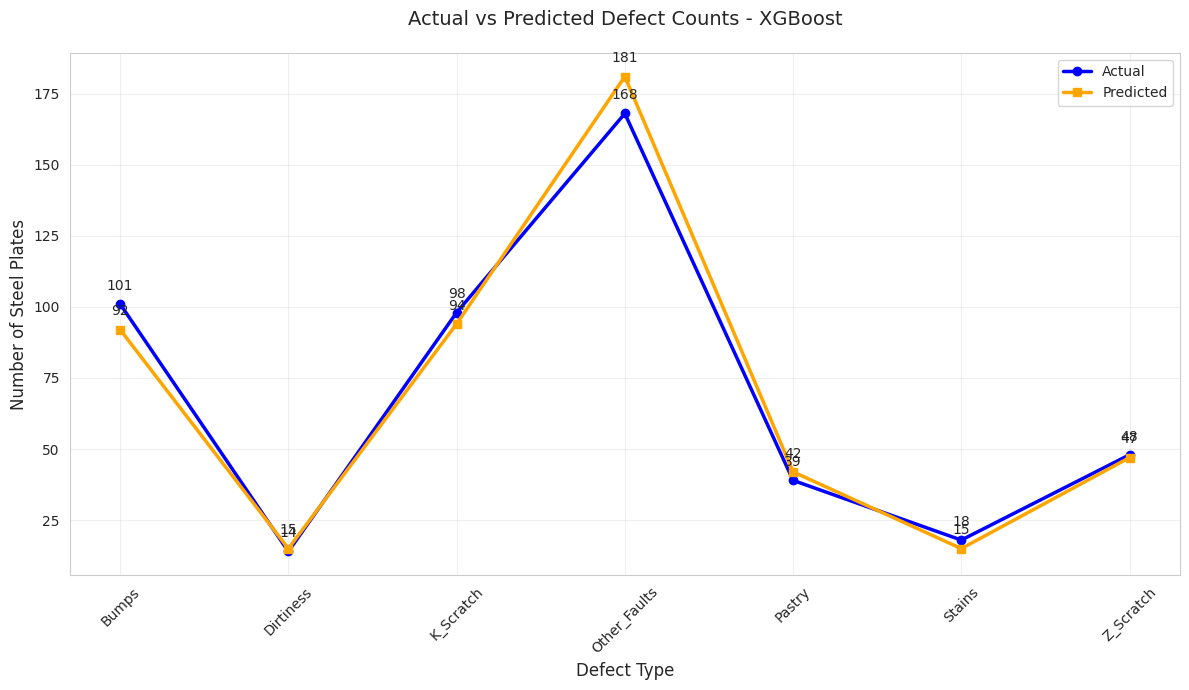

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Choose which model's predictions you want to visualize
# Options: y_pred_lr, y_pred_rf, or y_pred_xgb
y_pred = y_pred_xgb          # ← Change this line to test other models
model_name = "XGBoost"       # ← Update this too

# Class names in correct order (from LabelEncoder)
class_names = ['Bumps', 'Dirtiness', 'K_Scratch', 'Other_Faults',
               'Pastry', 'Stains', 'Z_Scratch']

# Count actual and predicted
actual_counts = pd.Series(y_test).value_counts().sort_index()
predicted_counts = pd.Series(y_pred).value_counts().sort_index()

# Create DataFrame for plotting
plot_df = pd.DataFrame({
    'Defect_Type': class_names,
    'Actual': actual_counts.values,
    'Predicted': predicted_counts.values
})

# Line Plot
plt.figure(figsize=(12, 7))
plt.plot(plot_df['Defect_Type'], plot_df['Actual'],
         marker='o', linewidth=2.5, label='Actual', color='blue')
plt.plot(plot_df['Defect_Type'], plot_df['Predicted'],
         marker='s', linewidth=2.5, label='Predicted', color='orange')

plt.title(f'Actual vs Predicted Defect Counts - {model_name}', fontsize=14, pad=20)
plt.xlabel('Defect Type', fontsize=12)
plt.ylabel('Number of Steel Plates', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)

# Add value labels on points
for i in range(len(plot_df)):
    plt.text(i, plot_df['Actual'][i] + 5, plot_df['Actual'][i], ha='center')
    plt.text(i, plot_df['Predicted'][i] + 5, plot_df['Predicted'][i], ha='center')

plt.tight_layout()
plt.show()

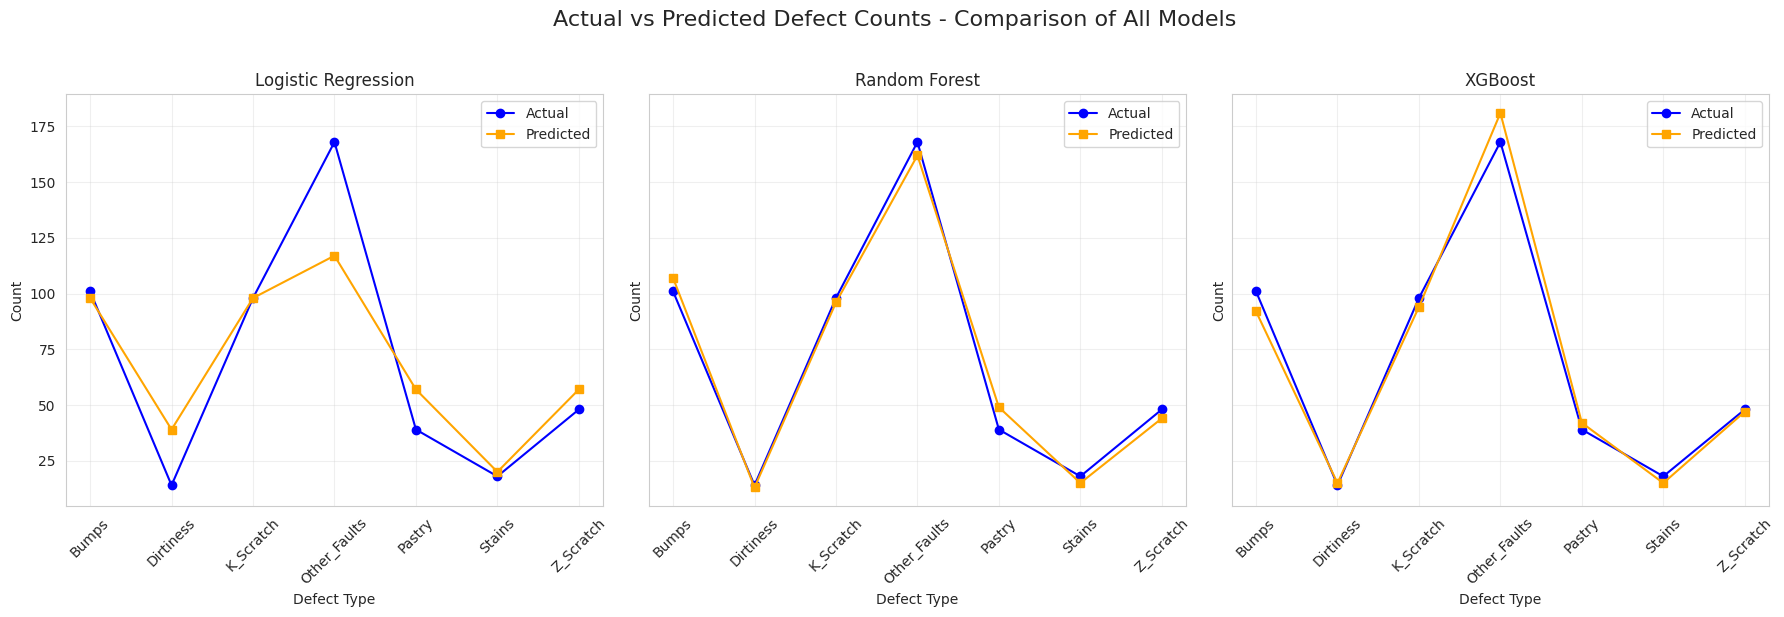

In [ ]:
# Actual vs Predicted for all three models in one figure

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

models = [
    ("Logistic Regression", y_pred_lr),
    ("Random Forest", y_pred_rf),
    ("XGBoost", y_pred_xgb)
]

for ax, (model_name, y_pred) in zip(axes, models):
    actual_counts = pd.Series(y_test).value_counts().sort_index()
    predicted_counts = pd.Series(y_pred).value_counts().sort_index()

    ax.plot(class_names, actual_counts.values, marker='o', label='Actual', color='blue')
    ax.plot(class_names, predicted_counts.values, marker='s', label='Predicted', color='orange')

    ax.set_title(model_name)
    ax.set_xlabel('Defect Type')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Actual vs Predicted Defect Counts - Comparison of All Models', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

The 'Actual vs Predicted Defect Counts - Comparison of All Models' graph visually demonstrates how well each model (Logistic Regression, Random Forest, and XGBoost) captures the distribution of the different defect types compared to the actual distribution.

**Logistic Regression** shows a notable discrepancy in predicting certain defect types, particularly underestimating 'Other_Faults' and overestimating 'Bumps' and 'Z_Scratch', indicating it struggles more with the class imbalance.

**Random Forest** generally follows the actual distribution much more closely than Logistic Regression, showing better predictive capabilities across most defect types.

**XGBoost** performs the best among the three, with its predicted counts aligning very closely with the actual counts for nearly all defect types. This suggests that XGBoost is the most robust model in replicating the true distribution of defects in the test set.

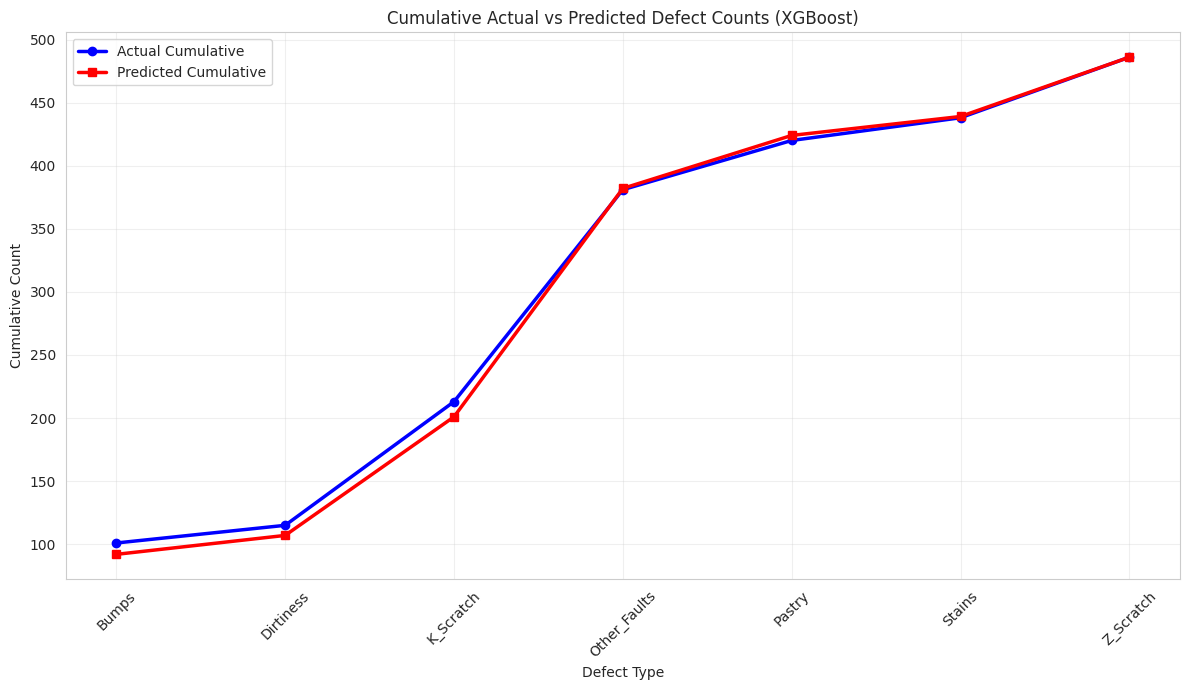

In [ ]:
# Cumulative Actual vs Predicted (shows how the model follows the trend)

actual_cum = pd.Series(y_test).value_counts().sort_index().cumsum()
predicted_cum = pd.Series(y_pred_xgb).value_counts().sort_index().cumsum()

plt.figure(figsize=(12, 7))
plt.plot(class_names, actual_cum, marker='o', linewidth=2.5, label='Actual Cumulative', color='blue')
plt.plot(class_names, predicted_cum, marker='s', linewidth=2.5, label='Predicted Cumulative', color='red')

plt.title('Cumulative Actual vs Predicted Defect Counts (XGBoost)')
plt.xlabel('Defect Type')
plt.ylabel('Cumulative Count')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_4710/17278904.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fi_df, x='Importance', y='Feature', palette='viridis')


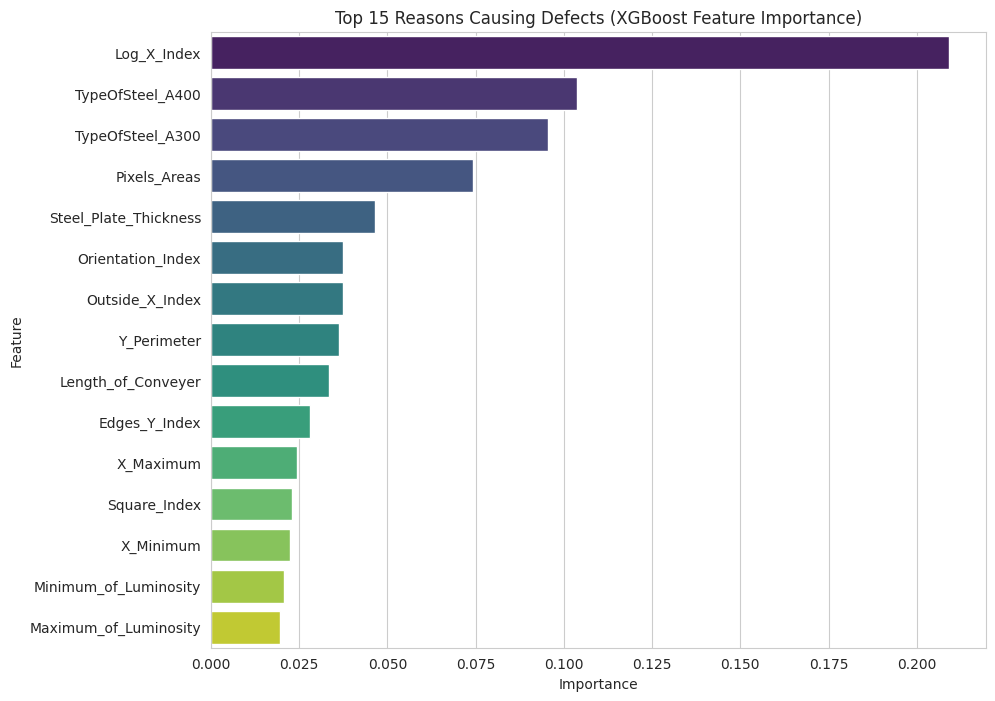

                  Feature  Importance
21            Log_X_Index    0.209109
11       TypeOfSteel_A400    0.103728
10       TypeOfSteel_A300    0.095556
4            Pixels_Areas    0.074394
12  Steel_Plate_Thickness    0.046445
23      Orientation_Index    0.037522
16        Outside_X_Index    0.037341
6             Y_Perimeter    0.036156
9      Length_of_Conveyer    0.033424
18          Edges_Y_Index    0.028112
1               X_Maximum    0.024465
15           Square_Index    0.023106
0               X_Minimum    0.022459
26  Minimum_of_Luminosity    0.020831
8   Maximum_of_Luminosity    0.019607


In [ ]:
# Step 11: Root Cause Analysis using XGBoost
importances = xgb_pipe.named_steps['classifier'].feature_importances_
feature_names = X.columns

fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
fi_df = fi_df.sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10,8))
sns.barplot(data=fi_df, x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Reasons Causing Defects (XGBoost Feature Importance)')
plt.show()

print(fi_df)

The 'Cumulative Actual vs Predicted Defect Counts (XGBoost)' graph illustrates how well the XGBoost model's predicted cumulative counts align with the actual cumulative counts across the sorted defect types. A close alignment between the 'Actual Cumulative' and 'Predicted Cumulative' lines indicates that the XGBoost model not only performs well on individual class predictions but also accurately captures the overall distribution and frequency trend of defects. The lines in the graph are very close, which signifies that the XGBoost model effectively replicates the true cumulative distribution of defects in the dataset, further affirming its robustness.

<Figure size 1200x800 with 0 Axes>

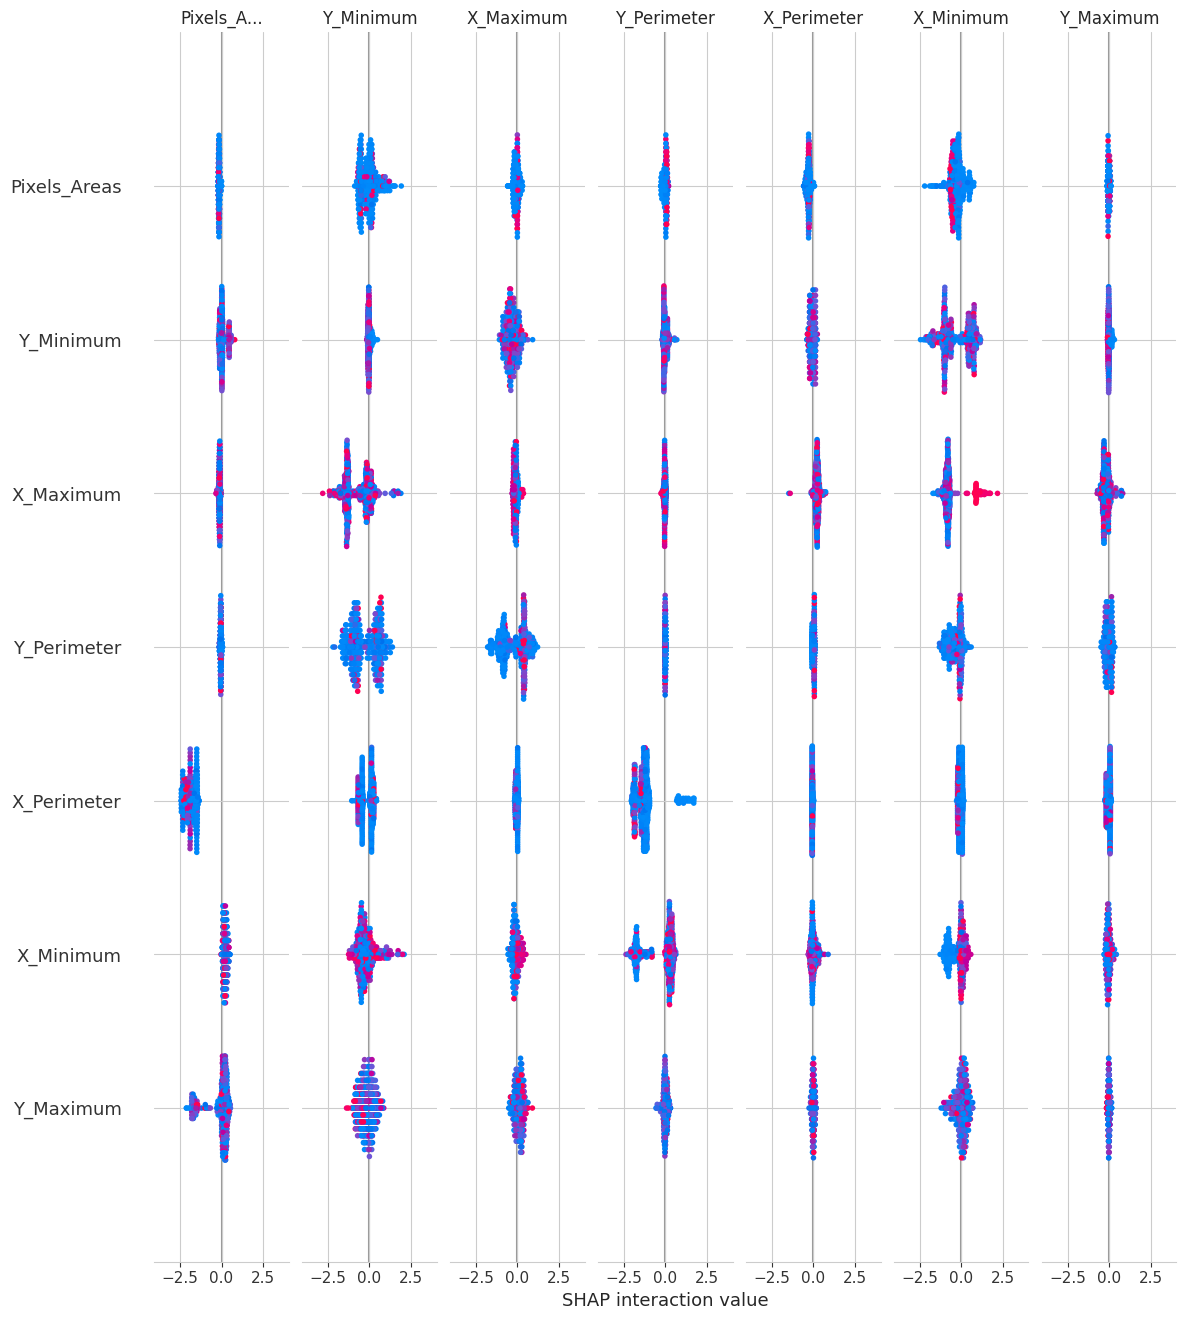

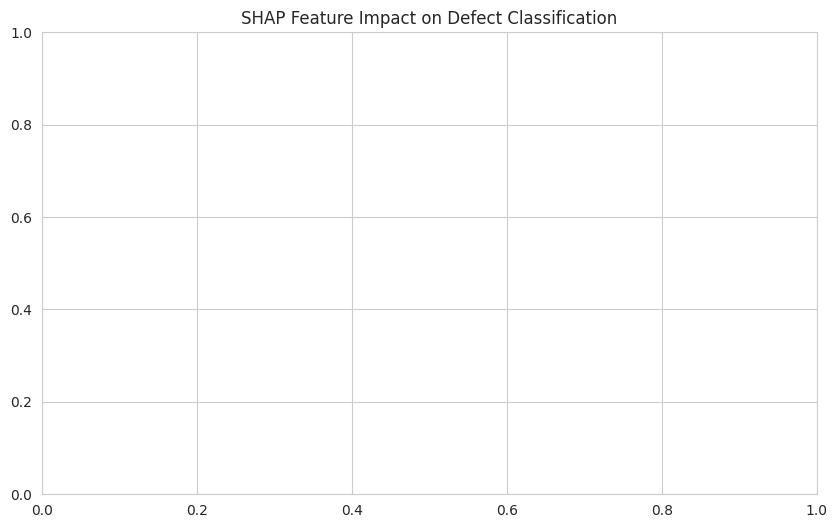

In [ ]:
# SHAP Analysis (install if needed)
!pip install shap -q

import shap

# Prepare explainer
explainer = shap.TreeExplainer(xgb_pipe.named_steps['classifier'])
X_test_transformed = xgb_pipe.named_steps['preprocessor'].transform(X_test)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test_transformed)

# Summary plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_transformed, feature_names=X.columns.tolist(), max_display=15)
plt.title("SHAP Feature Impact on Defect Classification")
plt.show()

In [ ]:
import joblib

# Save the best model (XGBoost)
joblib.dump(xgb_smote, 'xgboost_steel_defect_model.pkl')

# Also save the LabelEncoder and class names
joblib.dump(le, 'label_encoder.pkl')

print("Model and LabelEncoder saved successfully!")

Model and LabelEncoder saved successfully!
